In [127]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn import datasets
from sklearn.neural_network import MLPClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score

In [128]:
iris = datasets.load_iris()
X = iris.data
y = iris.target

X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.25, random_state=123456, stratify=y)

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_val = scaler.transform(X_val)

MLP with one hidden layer with 5 hidden nodes.

In [129]:
def mlp_1_5(solver):
    mlp = MLPClassifier(hidden_layer_sizes=(5,),
                        max_iter=10000,
                        warm_start=True,
                        solver=solver)

    val_scores = []
    iters = 50
    for i in range(iters):
        mlp.max_iter += 1
        mlp.fit(X_train, y_train)
        preds = mlp.predict(X_val)
        val_scores.append(accuracy_score(y_val, preds))
    return val_scores


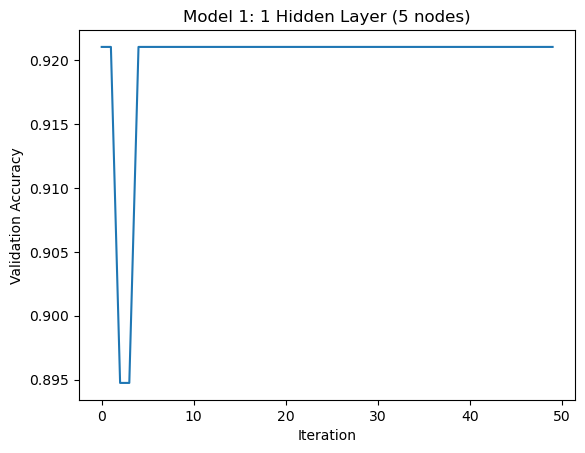

In [130]:
val_scores1 = mlp_1_5('adam')
plt.plot(val_scores1)
plt.xlabel("Iteration")
plt.ylabel("Validation Accuracy")
plt.title("Model 1: 1 Hidden Layer (5 nodes)")
plt.show()

MLP with three layers and two hidden nodes.

In [131]:
def mlp_3_2(solver):
    mlp = MLPClassifier(hidden_layer_sizes=(3,2),
                        max_iter=10000,
                        warm_start=True,
                        solver=solver)

    val_scores = []
    iters = 50
    for i in range(iters):
        mlp.max_iter += 1
        mlp.fit(X_train, y_train)
        preds = mlp.predict(X_val)
        val_scores.append(accuracy_score(y_val, preds))
    return val_scores


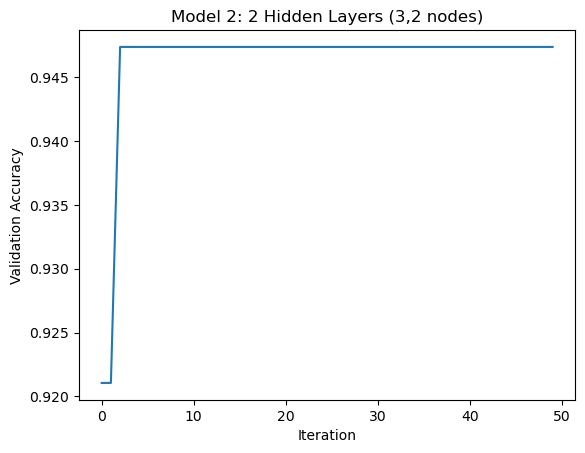

In [132]:
val_scores2 = mlp_3_2('adam')
plt.plot(val_scores2)
plt.xlabel("Iteration")
plt.ylabel("Validation Accuracy")
plt.title("Model 2: 2 Hidden Layers (3,2 nodes)")
plt.show()


Comparison.

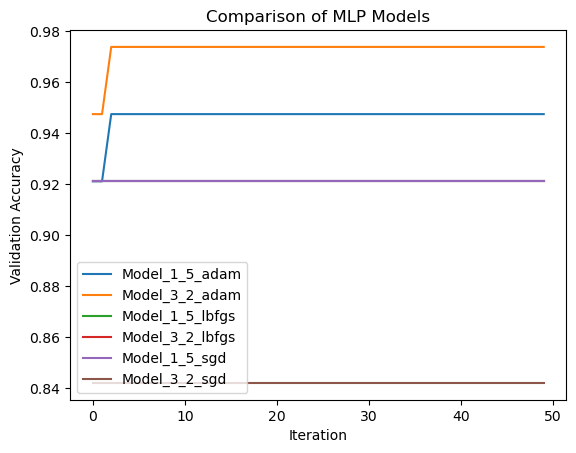

In [133]:
for solver in ['adam', 'lbfgs', 'sgd']:
    scores_1_5 = mlp_1_5(solver=solver)
    plt.plot(scores_1_5, label=f'Model_1_5_{solver}')

    scores_3_2 = mlp_1_5(solver=solver)
    plt.plot(scores_3_2, label=f'Model_3_2_{solver}')

plt.legend()
plt.xlabel("Iteration")
plt.ylabel("Validation Accuracy")
plt.title("Comparison of MLP Models")
plt.show()
